In [1]:
# FEATURE ENGINEERING

In [2]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# System & paths
import sys
import os
from pathlib import Path

In [4]:
# Project root (one level above notebooks/)
PROJECT_ROOT = Path.cwd().parents[0]
sys.path.append(str(PROJECT_ROOT))

In [5]:
from src.preprocessing import preprocess_pipeline, validate_no_missing

In [6]:
DATA_PATH = PROJECT_ROOT / "data" / "cleaned" / "State_Level_Allocations_Cleaned.csv"

In [7]:
# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

In [8]:
#Load dataset
df = pd.read_csv(DATA_PATH)
df['date'] = pd.to_datetime(df['date'])

In [9]:
df.shape

(2392, 4)

In [10]:
df.columns

Index(['state_code', 'date', 'commodity', 'total_allocated_qty'], dtype='object')

In [11]:
# Ensure date is datetime 
df['date'] = pd.to_datetime(df['date'])

earliest_date = df['date'].min()
latest_date = df['date'].max()

In [12]:
print("Earliest date", earliest_date)
print("Latest date", latest_date)

Earliest date 2017-01-31 00:00:00
Latest date 2021-10-31 00:00:00


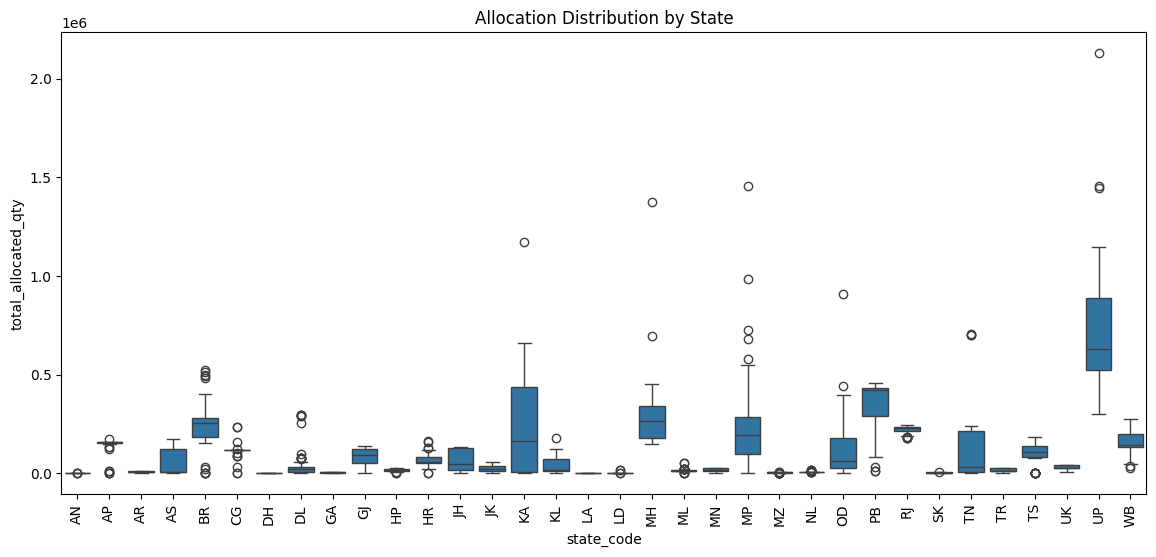

In [13]:
# checking states vs totsl_allocation
plt.figure(figsize=(14,6))
sns.boxplot(x='state_code', y='total_allocated_qty', data=df)

plt.xticks(rotation=90)
plt.title("Allocation Distribution by State")
plt.show()

In [14]:
# Preprocess
df_clean = preprocess_pipeline(df) 
# we expand timeline to all months for every state (), forwardfill the missing values,
# clip drastic outliers and validate no missing values for any state

e:\Learning\Data Science\Python_Projects\pds_foodgrain_forecasting\src\preprocessing.py:34: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  full_range = pd.date_range(
e:\Learning\Data Science\Python_Projects\pds_foodgrain_forecasting\src\preprocessing.py:34: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  full_range = pd.date_range(
e:\Learning\Data Science\Python_Projects\pds_foodgrain_forecasting\src\preprocessing.py:34: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  full_range = pd.date_range(
e:\Learning\Data Science\Python_Projects\pds_foodgrain_forecasting\src\preprocessing.py:34: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  full_range = pd.date_range(
e:\Learning\Data Science\Python_Projects\pds_foodgrain_forecasting\src\preprocessing.py:34: FutureWarning: 'M' is de

In [15]:
df_clean.shape

(2554, 4)

In [16]:
df_clean.columns

Index(['date', 'state_code', 'commodity', 'total_allocated_qty'], dtype='object')

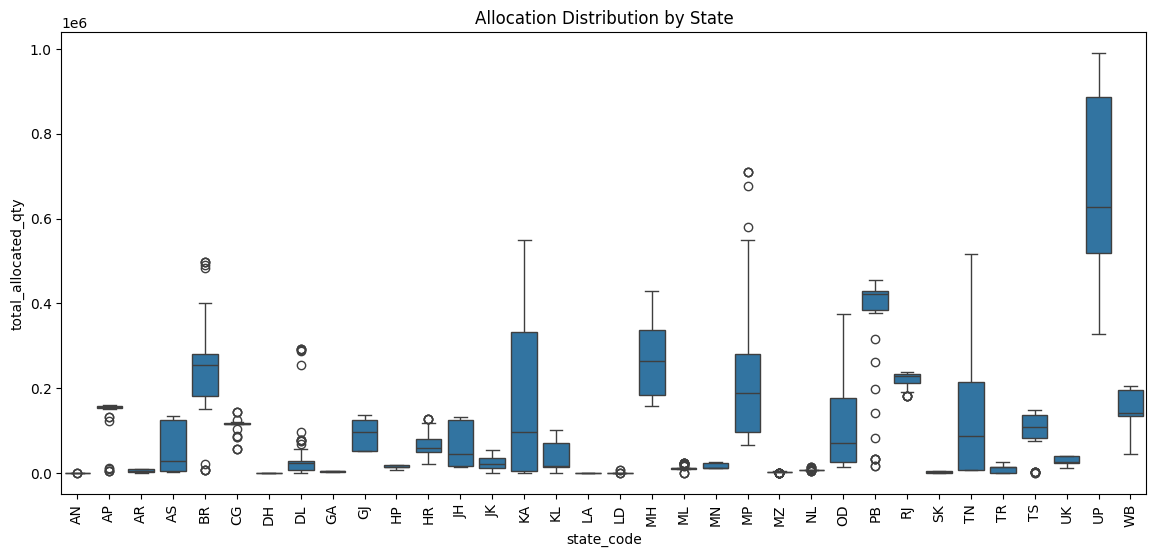

In [17]:
# checking states vs totsl_allocation
plt.figure(figsize=(14,6))
sns.boxplot(x='state_code', y='total_allocated_qty', data=df_clean)

plt.xticks(rotation=90)
plt.title("Allocation Distribution by State")
plt.show()

In [18]:
#Checking Timeline Continuity
check = (
    df_clean.groupby(['state_code', 'commodity'])['date']
            .apply(lambda x: x.is_monotonic_increasing)
)

print("All groups sorted:", check.all())


All groups sorted: True


In [19]:
#Checking for duplicates

duplicates = df_clean.duplicated(
    subset=['state_code', 'commodity', 'date']
).sum()

print("Duplicate rows:", duplicates)

Duplicate rows: 0


In [20]:
# Proceed to feature engineering
df_fe = df_clean.copy()
df_fe = df_fe.sort_values(['state_code', 'commodity', 'date'])

In [21]:
df_fe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2554 entries, 0 to 2553
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   date                 2554 non-null   datetime64[ns]
 1   state_code           2554 non-null   object        
 2   commodity            2554 non-null   object        
 3   total_allocated_qty  2554 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 79.9+ KB


In [22]:
df_fe.isna().sum()

date                   0
state_code             0
commodity              0
total_allocated_qty    0
dtype: int64

In [23]:
lags = [1, 2, 3, 6, 9, 12] # short-term inertia (dense recent memory)

In [24]:
# Calculating lag features
for lag in lags:
    df_fe[f'lag_{lag}'] = (
        df_fe.groupby(['state_code', 'commodity'])['total_allocated_qty']
             .shift(lag)
    )

In [25]:
# Calculating rolling mean features
df_fe['rolling_mean_3'] = (
    df_fe.groupby(['state_code', 'commodity'])['total_allocated_qty']
         .transform(lambda x: x.shift(1).rolling(3).mean())
)

df_fe['rolling_mean_6'] = (
    df_fe.groupby(['state_code', 'commodity'])['total_allocated_qty']
         .transform(lambda x: x.shift(1).rolling(6).mean())
)

In [26]:
# Calculating rolling std
df_fe['rolling_std_3'] = (
    df_fe.groupby(['state_code', 'commodity'])['total_allocated_qty']
         .transform(lambda x: x.shift(1).rolling(3).std())
)

In [27]:
df_model = df_fe.dropna().copy()

In [28]:
df_model.shape

(1873, 13)

In [29]:
group_sizes = df_model.groupby(['state_code', 'commodity']).size()

print(group_sizes.describe())

count    53.000000
mean     35.339623
std       4.714721
min      18.000000
25%      33.000000
50%      36.000000
75%      38.000000
max      45.000000
dtype: float64


In [30]:
feature_cols = [
    'lag_1', 'lag_2', 'lag_3',
    'lag_6', 'lag_9', 'lag_12',
    'rolling_mean_3', 'rolling_mean_6',
    'rolling_std_3'
]

target_col = 'total_allocated_qty'

corr_df = df_model[feature_cols + [target_col]].corr()

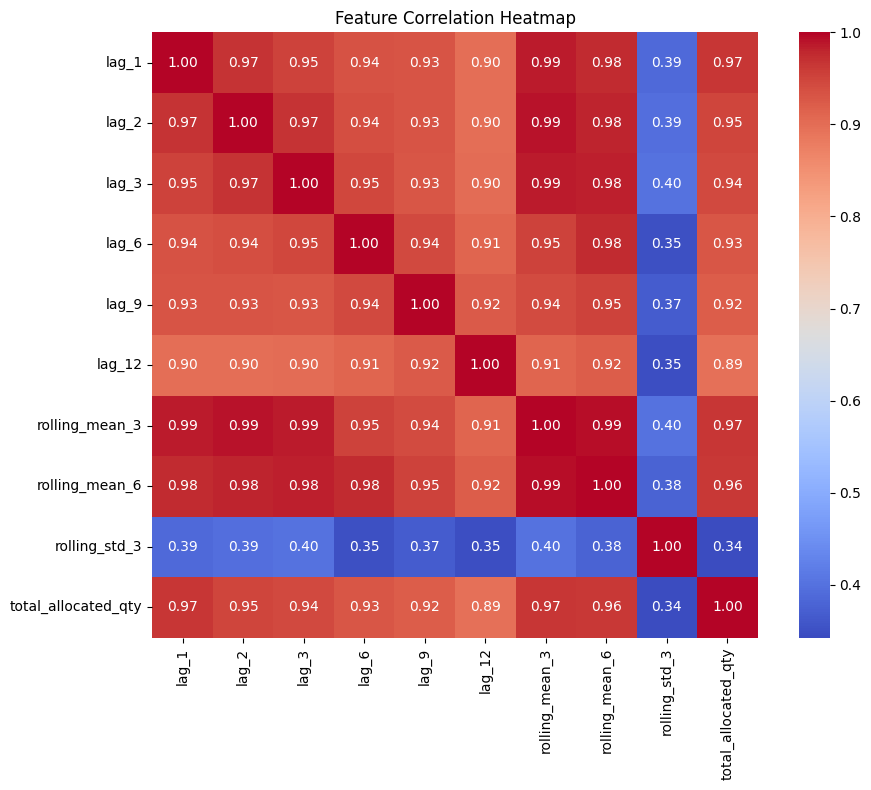

In [31]:
# Correlation visualisation
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_df,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True
)

plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

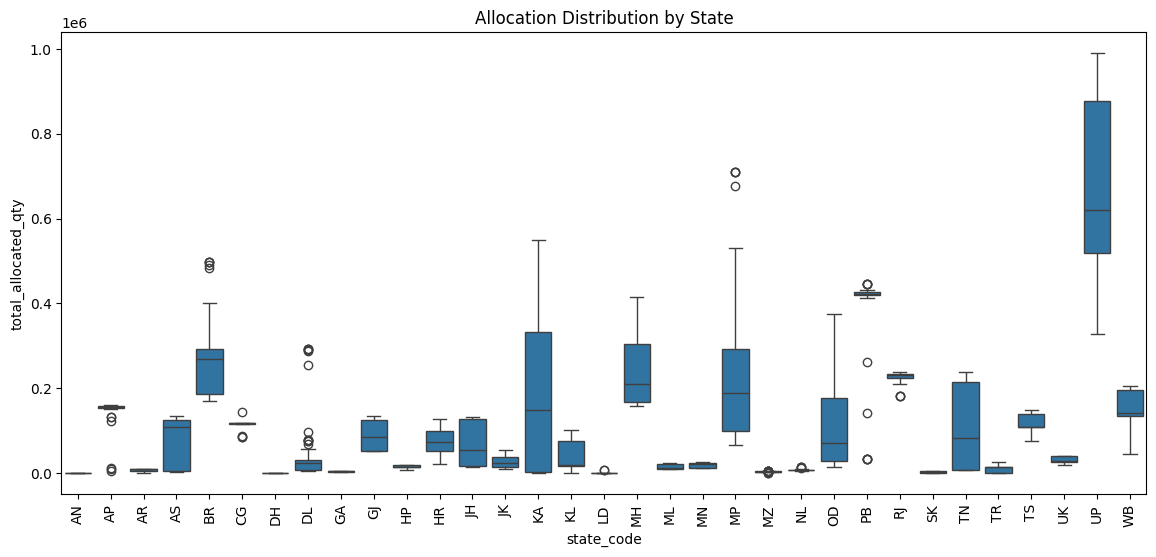

In [32]:
# checking states vs totsl_allocation
plt.figure(figsize=(14,6))
sns.boxplot(x='state_code', y='total_allocated_qty', data=df_model)

plt.xticks(rotation=90)
plt.title("Allocation Distribution by State")
plt.show()

In [33]:
df_model = df_model.sort_values(
    ['state_code', 'commodity', 'date']
).reset_index(drop=True)

In [34]:
os.makedirs("../data/preprocessed", exist_ok=True)

In [35]:
df_model.to_csv(
    "../data/preprocessed/state_level_features.csv",
    index=False
)